In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from  tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten,Dense,Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
# step 2: Data Preprocessing


# Training data generator
train_gen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Testing data generator
test_gen = ImageDataGenerator(
    rescale=1./255
)

# Dataset paths
train_path = r"C:\Users\dell\Downloads\training_set\training_set"
test_path = r"C:\Users\dell\Downloads\test_set\test_set"



In [4]:
# Load training dataset
train_data = train_gen.flow_from_directory(
    train_path,
    target_size = (128,128),
    batch_size = 32,
    class_mode = 'binary'
)
print(train_data.class_indices)

Found 8005 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


In [5]:
# Load testing dataset
test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)
print(test_data.class_indices)

Found 2023 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


In [6]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

C:\Users\dell\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer="adam",
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
es=EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [10]:
history=model.fit(
    train_data,
    validation_data=test_data,
    epochs=15,
    callbacks=[es]
)

Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 74s 290ms/step - accuracy: 0.5788 - loss: 0.6938 - val_accuracy: 0.6436 - val_loss: 0.6536
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 67s 267ms/step - accuracy: 0.6456 - loss: 0.6372 - val_accuracy: 0.6861 - val_loss: 0.6019
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 68s 270ms/step - accuracy: 0.6854 - loss: 0.5932 - val_accuracy: 0.7321 - val_loss: 0.5602
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 71s 282ms/step - accuracy: 0.7193 - loss: 0.5602 - val_accuracy: 0.7331 - val_loss: 0.5521
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 76s 302ms/step - accuracy: 0.7402 - loss: 0.5278 - val_accuracy: 0.7430 - val_loss: 0.5239
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 86391s 346s/step - accuracy: 0.7582 - loss: 0.4990 - val_accuracy: 0.7741 - val_loss: 0.4936
Epoch 7/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 153s 608ms/step - accuracy: 0.7714 - loss: 0.4747 - val_accuracy: 0.7736 - val_loss: 0.4943
Epoch 8/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 162s 648ms/step - accuracy: 0.7878 - los

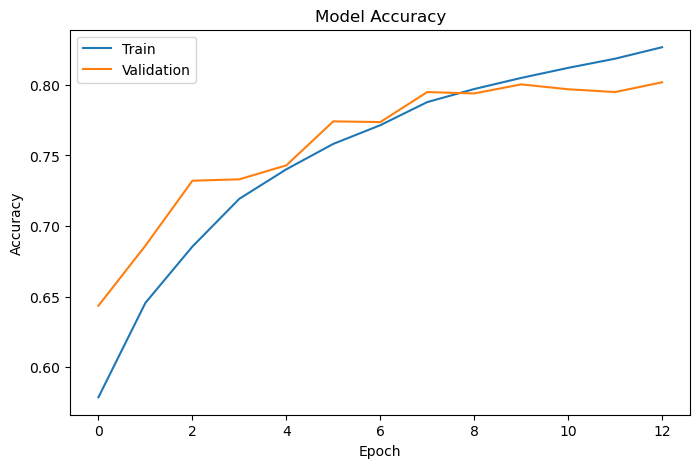

In [11]:
## step7: Accuracy grapgh
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

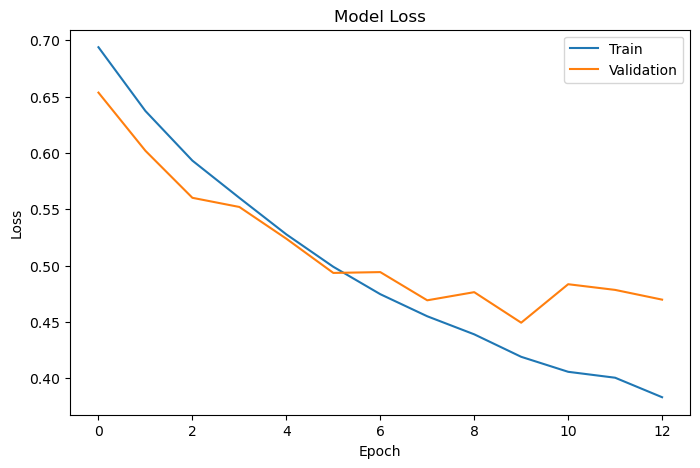

In [ ]:
# step 8: Loss Graph
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [ ]:
# step 9: Evaluate Model

loss,acc=model.evaluate(test_data)

print("Accuracy",acc)
print("Loss",loss)

64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - accuracy: 0.8003 - loss: 0.4494
Accuracy 0.8002966046333313
Loss 0.4493926167488098


In [ ]:
# step 10 :save model
model.save("cat_dog_cnn.h5")
print("Model saved successfully!")

Model saved successfully!


In [17]:
# step 11: load model
model=load_model("cat_dog_cnn.h5")

In [18]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))
Dense(3, activation='softmax')



<Dense name=dense_7, built=False>

In [19]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

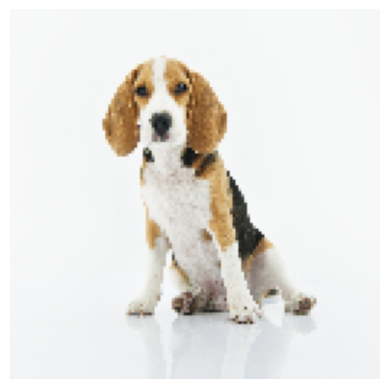

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Prediction Score: 0.5406757


In [35]:
# step 12: predict new Image
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load Image
img_path = r"C:\Users\dell\Downloads\beagle-dog-sitting-with-white-background.jpg"

img = image.load_img(
    img_path,
    target_size=(128,128)
)

# Display Image
plt.imshow(img)
plt.axis("off")
plt.show()

# Convert Image to Array
img_arr = image.img_to_array(img)

# Normalize
img_arr = img_arr / 255.0

# Add Batch Dimension
img_arr = np.expand_dims(img_arr, axis=0)

# Prediction
pred = model.predict(img_arr)

print("Prediction Score:", pred[0][0])

In [37]:
# step 13:final prediction
score = model.predict(img_arr, verbose=0)[0][0]

print(f"Prediction Score: {score:.4f}")

if score <= 0.53:
    print("Cat")
elif score > 0.540:
    print("Dog")
else:
    print("Unknown Object")

Prediction Score: 0.5407
Dog


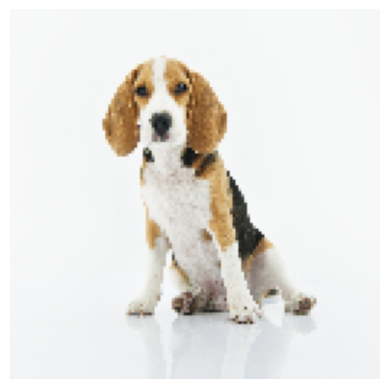

Dog


In [38]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Load image
img_path = r"C:\Users\dell\Downloads\beagle-dog-sitting-with-white-background.jpg"
img = load_img(
    img_path,
    target_size=(128,128)
)

# Display image
plt.imshow(img)
plt.axis("off")
plt.show()

# Convert image to array
img_arr = img_to_array(img)

# Normalize
img_arr = img_arr / 255.0

# Add batch dimension
img_arr = np.expand_dims(img_arr, axis=0)

# Predict
score = model.predict(img_arr, verbose=0)[0][0]

if score > 0.540:
    print("Dog")
elif score <= 0.53:
    print("Cat")
else:
    print("Unknown Object")
    
